<a href="https://colab.research.google.com/github/hasbiazif/Belajar/blob/Belajar/belajar_ML_cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Belajar Clustering**

## Import Libary dan upload datanya

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_excel('/content/file_contoh.xlsx')

In [4]:
print(df.head())

              peg_nip               peg_nama  \
0  197211272009012001            EVI YULIANI   
1  197302232007011008                HIDAYAT   
2  198107052010012005  NUNIK YUSNITA KUSWARA   
3  198112242015032001     KANIA DEWI NATALIA   
4  197504222010011003           BUDI PRANAYA   

                                       nama_jabatan satuan_kerja_nama  umur  \
0                         PENYUSUN LAPORAN KEUANGAN               BKD    52   
1                             PENGADMINISTRASI UMUM               BKD    52   
2  ANALIS SUMBER DAYA MANUSIA APARATUR AHLI PERTAMA               BKD    43   
3  ASESOR SUMBER DAYA MANUSIA APARATUR AHLI PERTAMA               BKD    43   
4  ANALIS SUMBER DAYA MANUSIA APARATUR AHLI PERTAMA               BKD    49   

   kinerja_rata  thp_bulan  masa_kerja kuisioner_opd_color  
0      99.08597    9785301          16              yellow  
1      95.53129    5341922          18                 red  
2      97.96887   13860352          15             ne

## rubah yang kategorik kasih label

In [6]:
# Encode zonasi
df["zonasi_encode"] = df["kuisioner_opd_color"].map({"red": 0, "orange": 1, "yellow": 2, "neutral": 3, "lightblue": 4, "blue": 5, "green": 6})

## pilih yang hanya numerik

In [7]:
fitur = df[["umur","kinerja_rata","thp_bulan","masa_kerja","zonasi_encode"]]

## Standarisasi

In [8]:
scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)

## Cluster menggunakan K-Means

In [9]:
# 6. KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(fitur_scaled)

## Visualisasi untuk cluster nya dengan PCA

In [10]:
from sklearn.decomposition import PCA

In [12]:
# PCA Visualisasi
pca = PCA(n_components=2)
pca_result = pca.fit_transform(fitur_scaled)
df["pca1"] = pca_result[:, 0]
df["pca2"] = pca_result[:, 1]

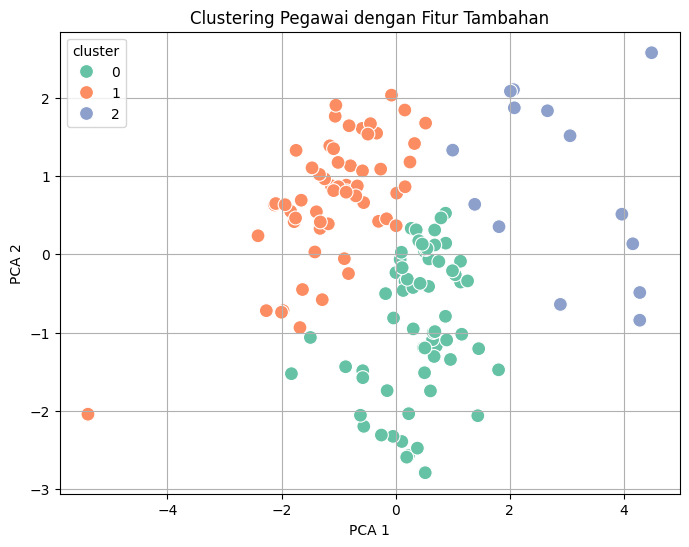

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster", palette="Set2", s=100)
plt.title("Clustering Pegawai dengan Fitur Tambahan")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

In [14]:
# 8. Lihat data dengan cluster
print(df[["peg_nip", "peg_nama", "nama_jabatan", "satuan_kerja_nama",  "umur", "kinerja_rata",  "thp_bulan",  "masa_kerja", "kuisioner_opd_color","zonasi_encode", "cluster"]])

                peg_nip               peg_nama  \
0    197211272009012001            EVI YULIANI   
1    197302232007011008                HIDAYAT   
2    198107052010012005  NUNIK YUSNITA KUSWARA   
3    198112242015032001     KANIA DEWI NATALIA   
4    197504222010011003           BUDI PRANAYA   
..                  ...                    ...   
134  196710202007011007                  CARLI   
135  196808202001121001         DINDI ZULKIFLI   
136  197204052008011004           DEDE PURNAMA   
137  199706292020082001      SHAFIRA NURAZIZAH   
138  197111122001122001           ENNY RUSTINI   

                                         nama_jabatan satuan_kerja_nama  umur  \
0                           PENYUSUN LAPORAN KEUANGAN               BKD    52   
1                               PENGADMINISTRASI UMUM               BKD    52   
2    ANALIS SUMBER DAYA MANUSIA APARATUR AHLI PERTAMA               BKD    43   
3    ASESOR SUMBER DAYA MANUSIA APARATUR AHLI PERTAMA               BKD    

In [15]:
df.to_excel("hasil_clustering_lengkap.xlsx", index=False)

In [ ]:
# Analisis karakteristik tiap cluster
cluster_summary = df.groupby("cluster")[[
    "umur", "masa_kerja", "gaji", "jumlah_project",
    "absensi", "jabatan_encoded", "pendidikan_encoded"
]].mean().round(2)

# Tambah jumlah anggota
cluster_summary["jumlah_anggota"] = df["cluster"].value_counts().sort_index()

# Reset index untuk tampil rapi
cluster_summary.reset_index(inplace=True)
cluster_summary


,cluster,umur,masa_kerja,gaji,jumlah_project,absensi,jabatan_encoded,pendidikan_encoded,jumlah_anggota
0,0,46.0,21.0,12.77,13.33,15.0,0.67,2.67,3
1,1,30.6,6.4,7.30,6.60,16.4,0.80,2.80,5
2,2,31.5,9.0,8.00,1.00,0.5,2.00,2.00,2


## dashboard WEB

In [1]:
pip install streamlit


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.7 MB/s eta 0:00:00


In [19]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import plotly.express as px

df = pd.read_excel("/content/hasil_clustering_lengkap (1).xlsx")

st.title("📊 Dashboard Segmentasi Pegawai")

st.subheader("Jumlah Pegawai per Cluster")
# Buat fig dari px.pie
fig = px.pie(df, names='cluster', title='Jumlah Pegawai per Cluster')

# Update tooltip/hover
fig.update_traces(
    hovertemplate="<b>Cluster: %{label}</b><br>Jumlah: %{value} orang<br>Persentase: %{percent}"
)
# Tampilkan chart
st.plotly_chart(fig)

st.subheader("Statistik Rata-rata per Cluster")
numeric_cols = ["umur", "kinerja_rata",  "thp_bulan",  "masa_kerja","zonasi_encode"]
for col in numeric_cols:
    st.plotly_chart(px.bar(df.groupby("cluster")[col].mean().reset_index(),
                           x="cluster", y=col, title=f"Rata-rata {col}"))

st.subheader("Visualisasi PCA (2D Cluster View)")
st.plotly_chart(px.scatter(df, x="pca1", y="pca2", color="cluster", title="Sebaran Cluster Berdasarkan PCA"))


Overwriting dashboard.py


In [6]:
!pip install pyngrok
from pyngrok import ngrok

In [8]:
!ngrok config add-authtoken *****

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [10]:
!streamlit run dashboard.py &>/dev/null &


In [15]:
# Pastikan terminate dulu tunnel sebelumnya (opsional tapi aman)
ngrok.kill()

# Buka tunnel HTTP ke port 8501
public_url = ngrok.connect("http://localhost:8501", bind_tls=True)
print(f"✅ Dashboard bisa diakses di: {public_url}")



✅ Dashboard bisa diakses di: NgrokTunnel: "https://1423-34-16-148-138.ngrok-free.app" -> "http://localhost:8501"


In [13]:
from pyngrok import ngrok

ngrok.kill()  # Tutup tunnel lama kalau ada
public_url = ngrok.connect(8501)
print(f"🔗 Buka dashboard di: {public_url}")


ERROR:pyngrok.process.ngrok:t=2025-04-09T07:22:17+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/secure-tunnels/ngrok-agent/reference/config\nYou can view your current agent sessions in the dashboard:\nhttps://dashboard.ngrok.com/agents\r\n\r\nERR_NGROK_108\r\n"
ERROR:pyngrok.process.ngrok:t=2025-04-09T07:22:17+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok st

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Your account is limited to 1 simultaneous ngrok agent sessions.\nYou can run multiple simultaneous tunnels from a single agent session by defining the tunnels in your agent configuration file and starting them with the command `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/secure-tunnels/ngrok-agent/reference/config\nYou can view your current agent sessions in the dashboard:\nhttps://dashboard.ngrok.com/agents\r\n\r\nERR_NGROK_108\r\n.

## pelengkap

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df["umur"], df["gaji"], c=df["cluster"], cmap='viridis')
plt.xlabel("Umur")
plt.ylabel("Gaji")
plt.title("Clustering Pegawai (Umur vs Gaji)")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Tambah kolom jabatan & project
df["jabatan"] = np.random.choice(["Staff", "Supervisor", "Manager"], size=len(df))
df["jumlah_project"] = np.random.randint(1, 16, size=len(df))

# Encode jabatan
df["jabatan_encoded"] = df["jabatan"].map({"Staff": 0, "Supervisor": 1, "Manager": 2})

# Tambah jumlah_project (acak 1–15)
df["jumlah_project"] = np.random.randint(1, 16, size=len(df))

# Tambah absensi (acak 0–30 hari absen)
df["absensi"] = np.random.randint(0, 31, size=len(df))